In [1]:
import os
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score, log_loss,
                             recall_score, balanced_accuracy_score, f1_score)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Kaggle dataset setup

Download `kmader/skin-cancer-mnist-ham10000` with `kagglehub`, reads `HAM10000_metadata.csv`, and maps each `image_id` to the corresponding JPG in the two image folders.

In [2]:
# Download the dataset from Kaggle

DATASET = "kmader/skin-cancer-mnist-ham10000"
data_dir = Path(kagglehub.dataset_download(DATASET))

print("Dataset directory:", data_dir)
print("Top-level files/folders:")
for path in sorted(data_dir.iterdir()):
    print(" -", path.name)

images_part_1_dir = data_dir / "HAM10000_images_part_1"
images_part_2_dir = data_dir / "HAM10000_images_part_2"

print("Number of images in 'HAM10000_images_part_1':", len(list(images_part_1_dir.glob("*.jpg"))))
print("Number of images in 'HAM10000_images_part_2':", len(list(images_part_2_dir.glob("*.jpg"))))

100%|██████████| 5.20G/5.20G [01:13<00:00, 75.6MB/s]

Extracting files...


Dataset directory: /root/.cache/kagglehub/datasets/kmader/skin-cancer-mnist-ham10000/versions/2
Top-level files/folders:
 - HAM10000_images_part_1
 - HAM10000_images_part_2
 - HAM10000_metadata.csv
 - ham10000_images_part_1
 - ham10000_images_part_2
 - hmnist_28_28_L.csv
 - hmnist_28_28_RGB.csv
 - hmnist_8_8_L.csv
 - hmnist_8_8_RGB.csv
Number of images in 'HAM10000_images_part_1': 5000
Number of images in 'HAM10000_images_part_2': 5015


In [3]:
# Load metadata and map every image_id to its JPG file

metadata = list(data_dir.rglob("HAM10000_metadata.csv"))
if not metadata:
    raise FileNotFoundError("HAM10000_metadata.csv was not found.")

metadata_path = metadata[0]
df = pd.read_csv(metadata_path)

# Images are stored across HAM10000_images_part_1 and part_2
image_files = list(data_dir.rglob("*.jpg"))
image_path_by_id = {path.stem: str(path) for path in image_files}
df["image_path"] = df["image_id"].map(image_path_by_id)

missing_images = df["image_path"].isna().sum()
if missing_images:
    missing_ids = df.loc[df["image_path"].isna(), "image_id"].head(10).tolist()
    raise FileNotFoundError(
        f"Could not locate {missing_images} image files. Example missing IDs: {missing_ids}"
    )

print(df.head())
print("Metadata shape:", df.shape)
print("Images discovered:", len(image_path_by_id))


     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                          image_path  
0  /root/.cache/kagglehub/datasets/kmader/skin-ca...  
1  /root/.cache/kagglehub/datasets/kmader/skin-ca...  
2  /root/.cache/kagglehub/datasets/kmader/skin-ca...  
3  /root/.cache/kagglehub/datasets/kmader/skin-ca...  
4  /root/.cache/kagglehub/datasets/kmader/skin-ca...  
Metadata shape: (10015, 8)
Images discovered: 10015


## Prepare labels to split Train/Test sets

In [4]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["dx"])
class_names = label_encoder.classes_

print("Classes:", list(enumerate(class_names)))
print("Full dataset shape:", df.shape)
print("Unique lesions:", df["lesion_id"].nunique())

Classes: [(0, 'akiec'), (1, 'bcc'), (2, 'bkl'), (3, 'df'), (4, 'mel'), (5, 'nv'), (6, 'vasc')]
Full dataset shape: (10015, 9)
Unique lesions: 7470


In [5]:
sgkf = StratifiedGroupKFold(
    n_splits=10,
    shuffle=True,
    random_state=RANDOM_STATE,
)

df["fold"] = -1
for fold, (_, fold_indices) in enumerate(
    sgkf.split(df, y=df["label"], groups=df["lesion_id"])
):
    df.loc[fold_indices, "fold"] = fold

test_fold = 0           # First fold is the test set.
validation_fold = 1     # Second fold is the validation set.

train_df = df.loc[~df["fold"].isin([test_fold, validation_fold])].copy()
val_df = df.loc[df["fold"] == validation_fold].copy()
test_df = df.loc[df["fold"] == test_fold].copy()

for split_name, split_df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}.items():
    print(
        f"{split_name:10s}: {len(split_df):5d} images, "
        f"{split_df['lesion_id'].nunique():5d} lesions"
    )
    print(split_df["dx"].value_counts(normalize=True).sort_index().round(3))
    print()

# Leakage checks: a lesion may belong to only one split.
train_lesions = set(train_df["lesion_id"])
val_lesions = set(val_df["lesion_id"])
test_lesions = set(test_df["lesion_id"])

assert train_lesions.isdisjoint(val_lesions)
assert train_lesions.isdisjoint(test_lesions)
assert val_lesions.isdisjoint(test_lesions)
assert len(train_df) + len(val_df) + len(test_df) == len(df)

print("No leakage: no lesion_id appears in multiple splits.")


train     :  7995 images,  5975 lesions
dx
akiec    0.031
bcc      0.049
bkl      0.111
df       0.013
mel      0.111
nv       0.672
vasc     0.014
Name: proportion, dtype: float64

validation:  1028 images,   748 lesions
dx
akiec    0.041
bcc      0.052
bkl      0.110
df       0.005
mel      0.115
nv       0.666
vasc     0.012
Name: proportion, dtype: float64

test      :   992 images,   747 lesions
dx
akiec    0.038
bcc      0.067
bkl      0.102
df       0.010
mel      0.112
nv       0.656
vasc     0.015
Name: proportion, dtype: float64

No leakage: no lesion_id appears in multiple splits.


In [6]:
# Dataframe process for CNN model
IMAGE_SIZE = (32, 32)

def load_image_array(image_path, size=IMAGE_SIZE):
    """Load one local JPG as a normalized RGB NumPy array."""
    with Image.open(image_path) as image:
        image = image.convert("RGB").resize(size)
        return np.asarray(image, dtype=np.float32) / 255.0


def dataframe_to_arrays(split_df):
    """Convert one metadata split into image and integer-label arrays."""
    X = np.stack([load_image_array(path) for path in split_df["image_path"]])
    y = split_df["label"].to_numpy(dtype=np.int64)
    return X, y

X_train, y_train = dataframe_to_arrays(train_df)
X_val, y_val = dataframe_to_arrays(val_df)
X_test, y_test = dataframe_to_arrays(test_df)

print("Training set:  ", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:      ", X_test.shape, y_test.shape)
print("Pixel range:", float(X_train.min()), "to", float(X_train.max()))

Training set:   (7995, 32, 32, 3) (7995,)
Validation set: (1028, 32, 32, 3) (1028,)
Test set:       (992, 32, 32, 3) (992,)
Pixel range: 0.0 to 1.0


## EDA & Preprocessing

In [7]:
print(train_df.head())
train_df.shape

     lesion_id      image_id   dx dx_type   age     sex localization  \
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0    male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0    male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0    male          ear   
5  HAM_0001466  ISIC_0027850  bkl   histo  75.0    male          ear   
8  HAM_0005132  ISIC_0025837  bkl   histo  70.0  female         back   

                                          image_path  label  fold  
2  /root/.cache/kagglehub/datasets/kmader/skin-ca...      2     5  
3  /root/.cache/kagglehub/datasets/kmader/skin-ca...      2     5  
4  /root/.cache/kagglehub/datasets/kmader/skin-ca...      2     5  
5  /root/.cache/kagglehub/datasets/kmader/skin-ca...      2     5  
8  /root/.cache/kagglehub/datasets/kmader/skin-ca...      2     5  


(7995, 10)

In [8]:
train_df.info()
train_df.describe().T
train_df.columns.tolist()

<class 'pandas.core.frame.DataFrame'>
Index: 7995 entries, 2 to 10014
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     7995 non-null   object 
 1   image_id      7995 non-null   object 
 2   dx            7995 non-null   object 
 3   dx_type       7995 non-null   object 
 4   age           7954 non-null   float64
 5   sex           7995 non-null   object 
 6   localization  7995 non-null   object 
 7   image_path    7995 non-null   object 
 8   label         7995 non-null   int64  
 9   fold          7995 non-null   int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 687.1+ KB


['lesion_id',
 'image_id',
 'dx',
 'dx_type',
 'age',
 'sex',
 'localization',
 'image_path',
 'label',
 'fold']

In [9]:
print("\nMissing values per column:")
display(train_df.isnull().sum())

print('\nDuplicate values per column:')
display(train_df.drop(columns=['image_path']).duplicated().sum())


Missing values per column:


,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,41
sex,0
localization,0
image_path,0
label,0
fold,0



Duplicate values per column:


np.int64(0)

In [10]:
print('\nFill missing values in \'age\' with the most common age:')
train_df['age'] = train_df['age'].fillna(train_df['age'].median())
display(train_df.isnull().sum())


Fill missing values in 'age' with the most common age:


,0
lesion_id,0
image_id,0
dx,0
dx_type,0
age,0
sex,0
localization,0
image_path,0
label,0
fold,0


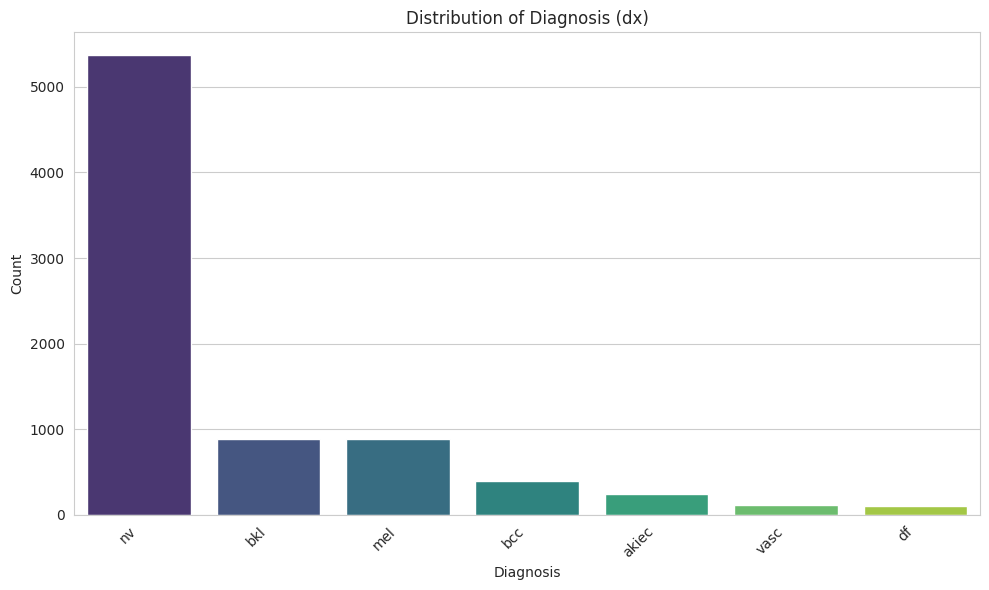

In [11]:
sns.set_style("whitegrid")

# 1. Distribution of 'dx' (diagnosis)
plt.figure(figsize=(10, 6))
sns.countplot(data=train_df, x='dx', order=train_df['dx'].value_counts().index, palette='viridis')
plt.title('Distribution of Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

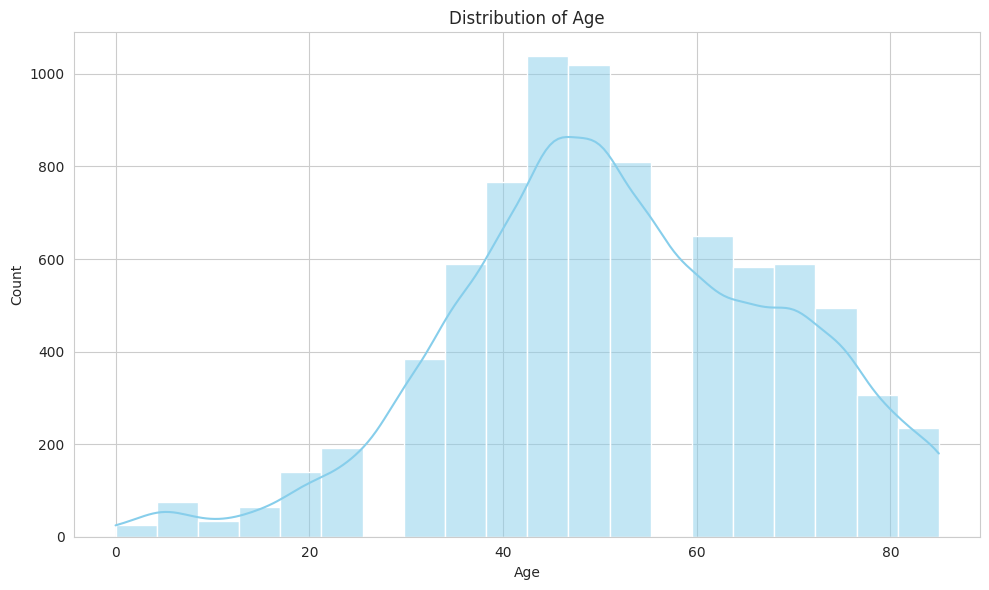

In [12]:
# 2. Distribution of 'age'
plt.figure(figsize=(10, 6))
sns.histplot(data=train_df, x='age', kde=True, bins=20, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

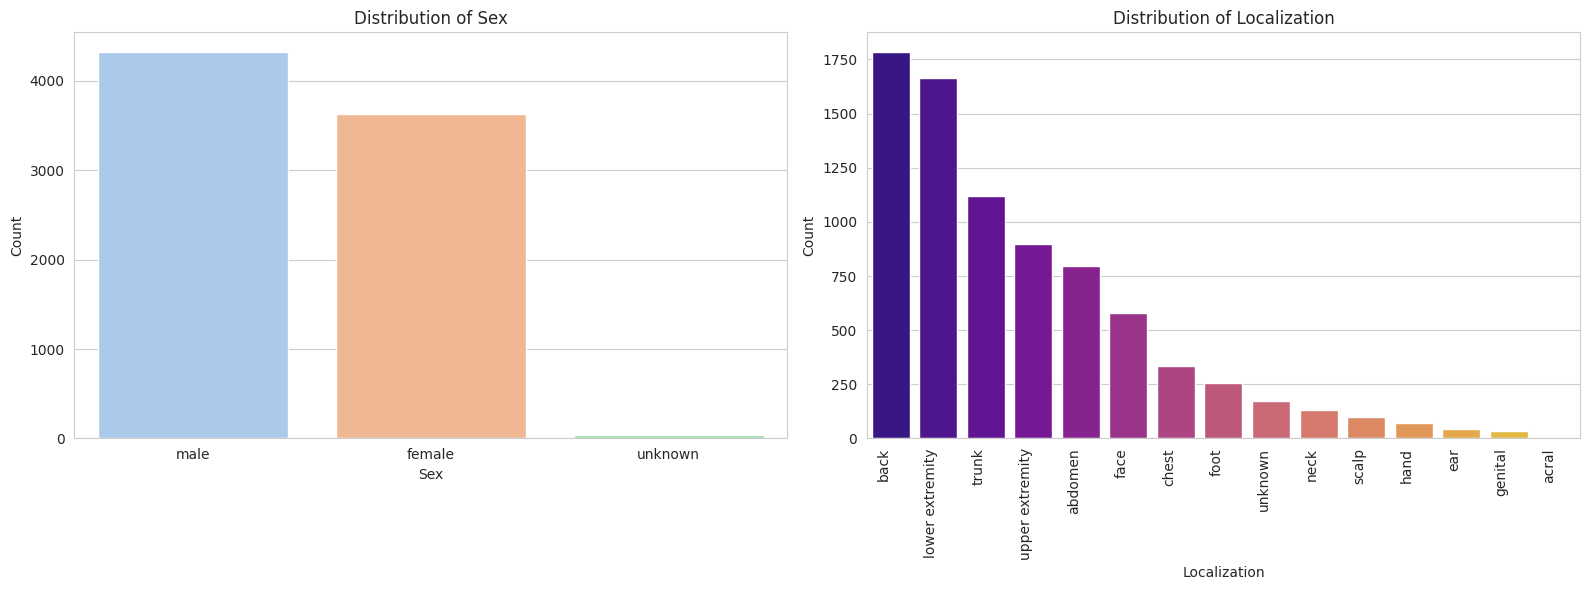

In [13]:
# 3. Distributions of 'sex' and 'localization'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=train_df, x='sex', ax=axes[0], palette='pastel', order=train_df['sex'].value_counts().index)
axes[0].set_title('Distribution of Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Count')

sns.countplot(data=train_df, x='localization', ax=axes[1], palette='plasma', order=train_df['localization'].value_counts().index)
axes[1].set_title('Distribution of Localization')
axes[1].set_xlabel('Localization')
axes[1].set_ylabel('Count')
plt.setp(axes[1].get_xticklabels(), rotation=90, horizontalalignment='right')

plt.tight_layout()
plt.show()

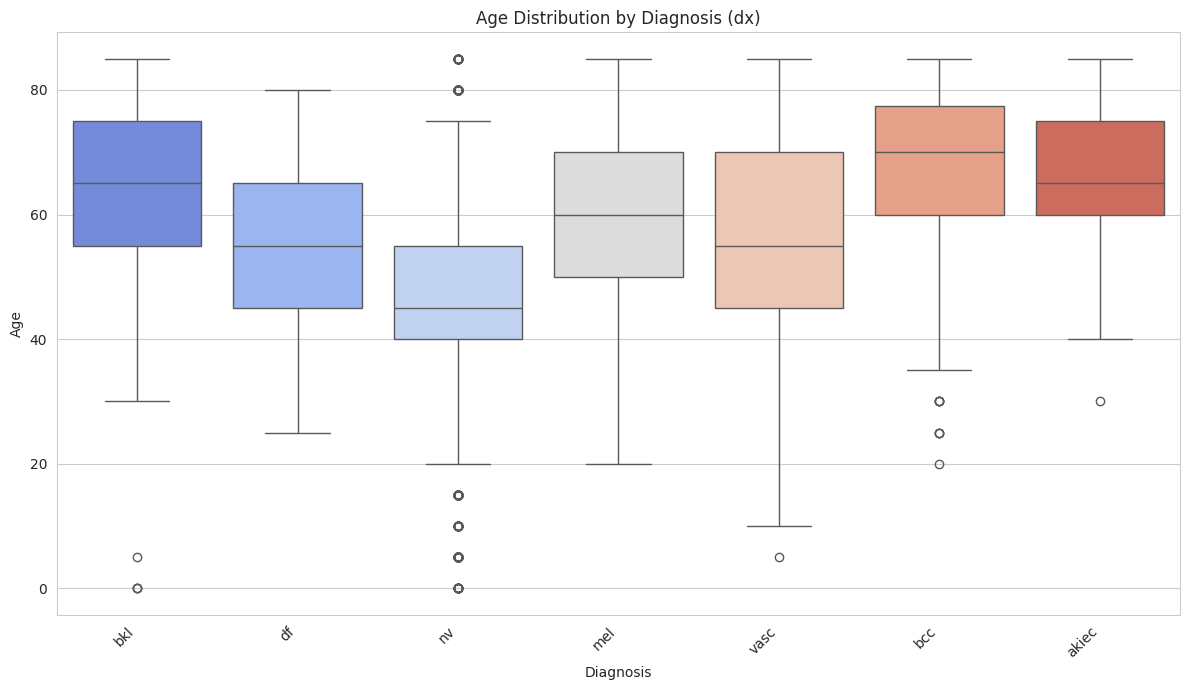

In [14]:
# 4. Age distribution by 'dx'
plt.figure(figsize=(12, 7))
sns.boxplot(data=train_df, x='dx', y='age', palette='coolwarm')
plt.title('Age Distribution by Diagnosis (dx)')
plt.xlabel('Diagnosis')
plt.ylabel('Age')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5. Detect and handle image outliers

Brightness and contrast limits are calculated from the **training set only** with the IQR rule. Flagged training images are displayed and then removed before any model is trained. The validation and test sets are not modified, which prevents test-data leakage.


In [15]:
# X_train is already RGB, resized to 32 × 32 × 3, and scaled to 0–1.
train_brightness = X_train.mean(axis=(1, 2, 3))
train_contrast = X_train.std(axis=(1, 2, 3))


def iqr_outlier_mask(values):
    values = np.asarray(values)
    q1 = np.quantile(values, 0.25)
    q3 = np.quantile(values, 0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (values < lower) | (values > upper)
    return mask, lower, upper


brightness_outlier, brightness_lower, brightness_upper = iqr_outlier_mask(
    train_brightness
)
contrast_outlier, contrast_lower, contrast_upper = iqr_outlier_mask(
    train_contrast
)
train_outlier_mask = brightness_outlier | contrast_outlier

train_metadata_aligned = train_df.reset_index(drop=True)
train_quality_df = pd.DataFrame({
    "training_row": np.arange(len(X_train)),
    "image_id": train_metadata_aligned["image_id"],
    "lesion_id": train_metadata_aligned["lesion_id"],
    "dx": train_metadata_aligned["dx"],
    "brightness": train_brightness,
    "contrast": train_contrast,
    "brightness_outlier": brightness_outlier,
    "contrast_outlier": contrast_outlier,
    "potential_outlier": train_outlier_mask,
})

print("Training images checked:", len(train_quality_df))
print("Brightness limits:", round(brightness_lower, 4), "to", round(brightness_upper, 4))
print("Contrast limits:", round(contrast_lower, 4), "to", round(contrast_upper, 4))
print("Brightness outliers flagged:", int(brightness_outlier.sum()))
print("Contrast outliers flagged:", int(contrast_outlier.sum()))
print("Unique training outliers flagged:", int(train_outlier_mask.sum()))
display(train_quality_df[["brightness", "contrast"]].describe())


Training images checked: 7995
Brightness limits: 0.4246 to 0.8281
Contrast limits: 0.0141 to 0.2995
Brightness outliers flagged: 67
Contrast outliers flagged: 8
Unique training outliers flagged: 75


,brightness,contrast
count,7995.000000,7995.000000
mean,0.626808,0.157764
std,0.074901,0.045669
min,0.249272,0.039369
25%,0.575924,0.121115
50%,0.627002,0.161783
75%,0.676776,0.192452
max,0.908923,0.324806


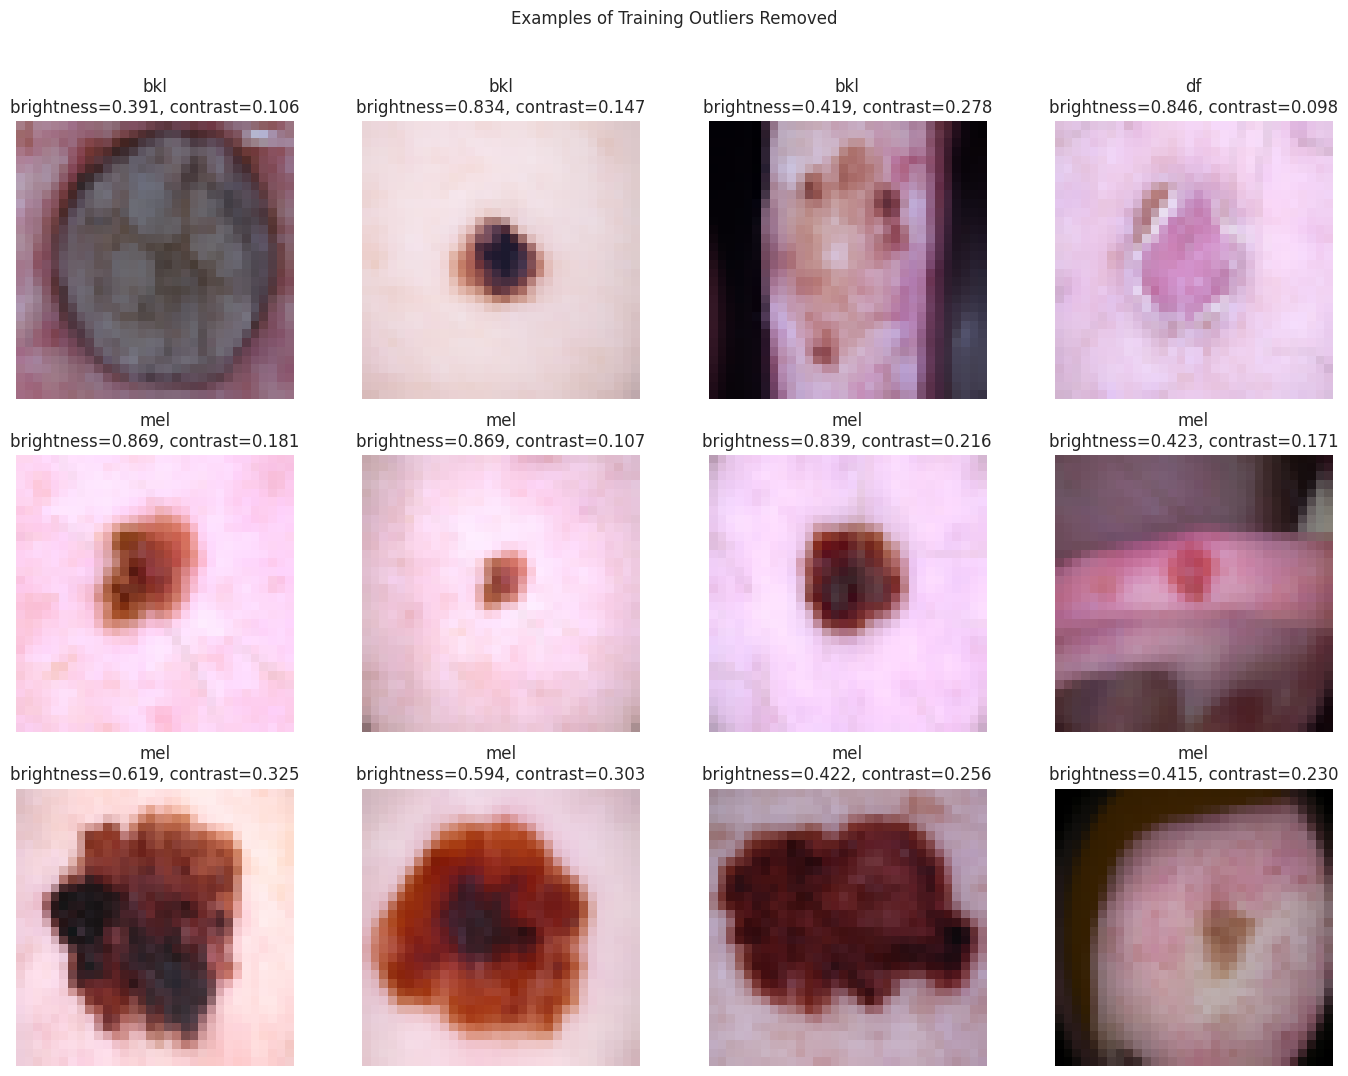

Original training images: 7995
Training outliers removed: 75
Training images remaining: 7920
Validation images unchanged: 1028
Test images unchanged: 992

Removed images by diagnosis:


,dx,removed_count
0,nv,52
1,mel,17
2,bkl,3
3,vasc,2
4,df,1


In [16]:
# Display at most 12 examples, but handle every flagged training image.
outlier_indices = np.flatnonzero(train_outlier_mask)
example_indices = outlier_indices[:12]

if len(example_indices) == 0:
    print("No brightness or contrast outliers were flagged.")
else:
    columns = 4
    rows = int(np.ceil(len(example_indices) / columns))
    plt.figure(figsize=(14, 3.5 * rows))

    for plot_number, training_index in enumerate(example_indices, start=1):
        plt.subplot(rows, columns, plot_number)
        plt.imshow(X_train[training_index])
        plt.title(
            f"{class_names[int(y_train[training_index])]}\n"
            f"brightness={train_brightness[training_index]:.3f}, "
            f"contrast={train_contrast[training_index]:.3f}"
        )
        plt.axis("off")

    plt.suptitle("Examples of Training Outliers Removed", y=1.02)
    plt.tight_layout()
    plt.show()

TRAIN_SIZE_BEFORE_OUTLIERS = len(X_train)
OUTLIERS_REMOVED = int(train_outlier_mask.sum())
keep_training_rows = ~train_outlier_mask

removed_outliers_df = train_quality_df.loc[
    train_outlier_mask,
    ["training_row", "image_id", "lesion_id", "dx", "brightness", "contrast"],
].copy()

# Apply the same mask to images, labels, and aligned training metadata.
X_train = X_train[keep_training_rows].copy()
y_train = y_train[keep_training_rows].copy()
train_df = train_metadata_aligned.loc[keep_training_rows].reset_index(drop=True)

assert len(X_train) == len(y_train) == len(train_df)
assert set(np.unique(y_train)) == set(np.arange(len(class_names)))

print("Original training images:", TRAIN_SIZE_BEFORE_OUTLIERS)
print("Training outliers removed:", OUTLIERS_REMOVED)
print("Training images remaining:", len(X_train))
print("Validation images unchanged:", len(X_val))
print("Test images unchanged:", len(X_test))

print("\nRemoved images by diagnosis:")
display(
    removed_outliers_df["dx"]
    .value_counts()
    .rename_axis("dx")
    .reset_index(name="removed_count")
)


In [27]:
removed_ids = set(removed_outliers_df["image_id"])
remaining_ids = set(train_df["image_id"])

overlap = removed_ids & remaining_ids

print("Removed image IDs:", len(removed_ids))
print("Removed IDs still in training data:", len(overlap))

assert len(overlap) == 0

print("All flagged outliers were removed successfully.")

Removed image IDs: 75
Removed IDs still in training data: 0
All flagged outliers were removed successfully.


In [17]:
# 6. Handle Class Imbalance

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes, weights)
}
print(class_weights)

{0: 4.580682475419318, 1: 2.864376130198915, 2: 1.282798833819242, 3: 11.428571428571429, 4: 1.304992585269402, 5: 0.21279454042290227, 6: 10.012642225031605}


## Training Models Part

In [18]:
ALL_LABELS = np.arange(len(class_names))


def evaluate_part2_model(model, model_name, X_eval, y_eval):
    predictions = model.predict(X_eval)
    probabilities = model.predict_proba(X_eval)

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_eval, predictions),
        "Balanced Accuracy": balanced_accuracy_score(y_eval, predictions),
        "Macro Precision": precision_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_eval, predictions, labels=ALL_LABELS,
            average="macro", zero_division=0
        ),
        "Log Loss": log_loss(y_eval, probabilities, labels=ALL_LABELS),
    }

    print(f"\n{model_name}")
    print("=" * len(model_name))
    for metric, value in result.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_eval,
        predictions,
        labels=ALL_LABELS,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))

    cm = confusion_matrix(y_eval, predictions, labels=ALL_LABELS)
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return result, predictions


In [19]:
# Dataframe process for Logistic Regression and Random Forest models
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(X_train_flat.shape)
print(X_val_flat.shape)
print(X_test_flat.shape)

(7920, 3072)
(1028, 3072)
(992, 3072)


## Majority Class Baseline

Majority class: nv

Majority Class Baseline
Accuracy: 0.6562
Balanced Accuracy: 0.1429
Macro Precision: 0.0938
Macro Recall: 0.1429
Macro F1: 0.1132
Log Loss: 12.3900

Classification Report:
              precision    recall  f1-score   support

       akiec     0.0000    0.0000    0.0000        38
         bcc     0.0000    0.0000    0.0000        66
         bkl     0.0000    0.0000    0.0000       101
          df     0.0000    0.0000    0.0000        10
         mel     0.0000    0.0000    0.0000       111
          nv     0.6562    1.0000    0.7925       651
        vasc     0.0000    0.0000    0.0000        15

    accuracy                         0.6562       992
   macro avg     0.0938    0.1429    0.1132       992
weighted avg     0.4307    0.6562    0.5200       992



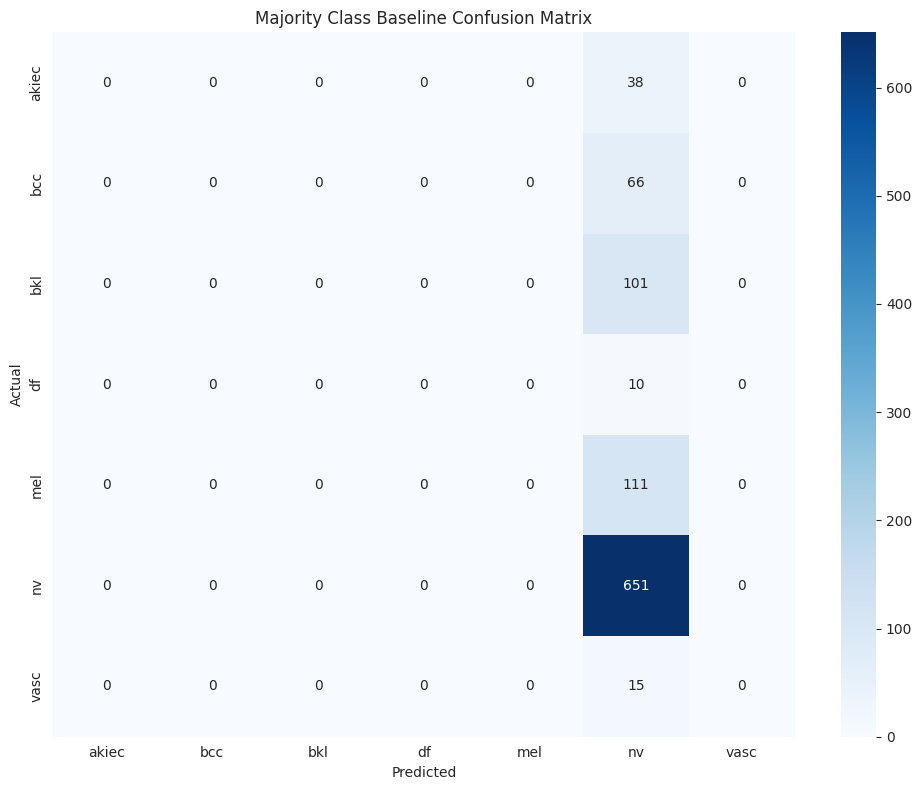

In [20]:
majority_baseline = DummyClassifier(
    strategy="most_frequent",
    random_state=42,
)
majority_baseline.fit(X_train_flat, y_train)

majority_class_id = int(majority_baseline.predict(X_train_flat[:1])[0])
print("Majority class:", class_names[majority_class_id])

majority_result, majority_predictions = evaluate_part2_model(
    majority_baseline,
    "Majority Class Baseline",
    X_test_flat,
    y_test,
)

## Logistic Regression Model

Training Logistic Regression...

Logistic Regression
Accuracy: 0.3700
Balanced Accuracy: 0.3244
Macro Precision: 0.3136
Macro Recall: 0.3244
Macro F1: 0.2241
Log Loss: 2.7911

Classification Report:
              precision    recall  f1-score   support

       akiec     0.5000    0.0789    0.1364        38
         bcc     0.1481    0.0606    0.0860        66
         bkl     0.0000    0.0000    0.0000       101
          df     0.0194    0.9000    0.0379        10
         mel     0.3603    0.4414    0.3968       111
          nv     0.8735    0.4562    0.5994       651
        vasc     0.2941    0.3333    0.3125        15

    accuracy                         0.3700       992
   macro avg     0.3136    0.3244    0.2241       992
weighted avg     0.6472    0.3700    0.4538       992



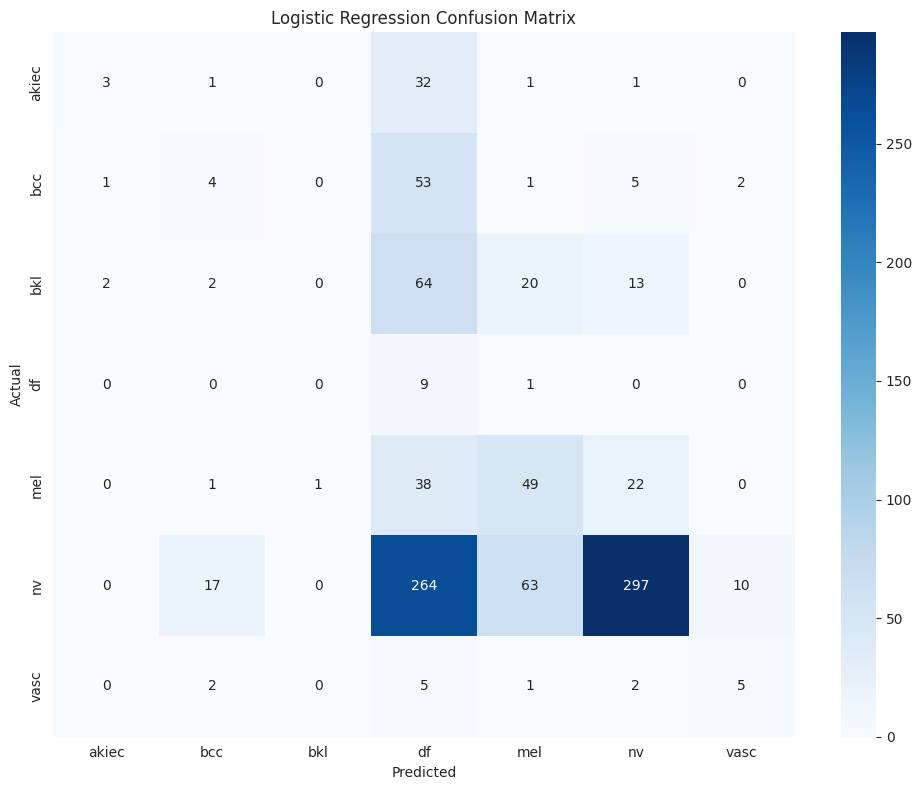

In [21]:
RUN_LOGISTIC_REGRESSION = True

if RUN_LOGISTIC_REGRESSION:
    logistic_model = LogisticRegression(
        solver="saga",
        C=1.0,
        max_iter=500,
        tol=1e-3,
        class_weight=class_weights,
        random_state=42,
    )

    print("Training Logistic Regression...")
    logistic_model.fit(X_train_flat, y_train)

    logistic_result, logistic_predictions = evaluate_part2_model(
        logistic_model,
        "Logistic Regression",
        X_test_flat,
        y_test,
    )
else:
    logistic_model = None
    logistic_result = None
    print("Logistic Regression skipped.")

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1,Log Loss
0,Majority Class Baseline,0.6562,0.1429,0.0938,0.1429,0.1132,12.3900
1,Logistic Regression,0.3700,0.3244,0.3136,0.3244,0.2241,2.7911


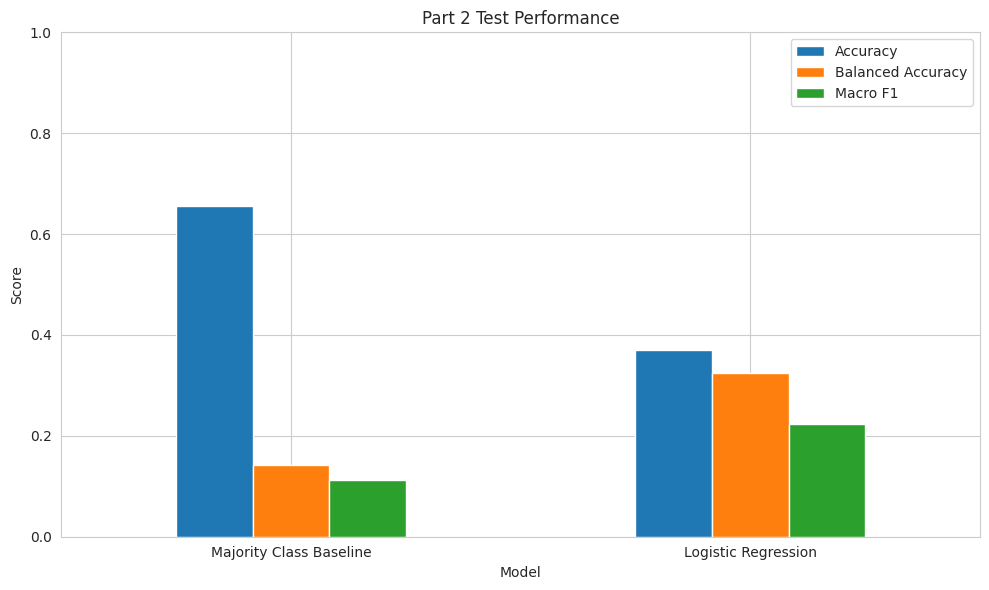

In [22]:
part2_results_df = pd.DataFrame([
    majority_result,
    logistic_result,
])

display(part2_results_df.round(4))

# Log loss is shown in the table but not in this chart because it is not a 0–1 score.
plot_metrics = ["Accuracy", "Balanced Accuracy", "Macro F1"]
part2_results_df.set_index("Model")[plot_metrics].plot(
    kind="bar",
    figsize=(10, 6),
    ylim=(0, 1),
    rot=0,
)

plt.title("Part 2 Test Performance")
plt.ylabel("Score")
plt.tight_layout()
plt.show()


### Part 2 analysis

The Majority Class Baseline ignores image information and always predicts the most frequent cleaned training class. Its ordinary accuracy can appear reasonable in an imbalanced dataset, while balanced accuracy and macro-F1 reveal its failure to identify minority classes.

Logistic Regression uses the scaled pixel values and class weights, so it can pay more attention to minority classes. However, flattening each image removes its two-dimensional spatial structure; consequently, it cannot learn lesion shapes and textures as effectively as image-specific CNN models. Lower log loss indicates better probability estimates, and it should be interpreted as a raw loss value rather than a percentage.


In [23]:
baseline_row = part2_results_df.loc[
    part2_results_df["Model"] == "Majority Class Baseline"
].iloc[0]
logistic_row = part2_results_df.loc[
    part2_results_df["Model"] == "Logistic Regression"
].iloc[0]

print("PART 2 RESULT SUMMARY")
print("=" * 60)
print(f"Training outliers removed: {OUTLIERS_REMOVED}")
print(
    f"Majority baseline — accuracy: {baseline_row['Accuracy']:.2%}, "
    f"balanced accuracy: {baseline_row['Balanced Accuracy']:.2%}, "
    f"macro-F1: {baseline_row['Macro F1']:.2%}, "
    f"log loss: {baseline_row['Log Loss']:.4f}"
)
print(
    f"Logistic Regression — accuracy: {logistic_row['Accuracy']:.2%}, "
    f"balanced accuracy: {logistic_row['Balanced Accuracy']:.2%}, "
    f"macro-F1: {logistic_row['Macro F1']:.2%}, "
    f"log loss: {logistic_row['Log Loss']:.4f}"
)


PART 2 RESULT SUMMARY
Training outliers removed: 75
Majority baseline — accuracy: 65.62%, balanced accuracy: 14.29%, macro-F1: 11.32%, log loss: 12.3900
Logistic Regression — accuracy: 37.00%, balanced accuracy: 32.44%, macro-F1: 22.41%, log loss: 2.7911


## Random Forest Model

In [24]:
# Train Random Forest Classifier

print("Random Forest training shape:", X_train_flat.shape)
print("Random Forest test shape:", X_test_flat.shape)

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_train_flat, y_train)


Random Forest training shape: (7920, 3072)
Random Forest test shape: (992, 3072)


RandomForestClassifier(class_weight={0: 4.580682475419318, 1: 2.864376130198915,
                                     2: 1.282798833819242,
                                     3: 11.428571428571429,
                                     4: 1.304992585269402,
                                     5: 0.21279454042290227,
                                     6: 10.012642225031605},
                       n_jobs=-1, random_state=42)

Random Forest Accuracy: 0.6915322580645161
Random Forest Balanced Accuracy: 0.23300918600433757

Classification Report:
              precision    recall  f1-score   support

       akiec       0.40      0.05      0.09        38
         bcc       0.48      0.18      0.26        66
         bkl       0.58      0.30      0.39       101
          df       1.00      0.10      0.18        10
         mel       0.40      0.02      0.03       111
          nv       0.71      0.98      0.82       651
        vasc       0.00      0.00      0.00        15

    accuracy                           0.69       992
   macro avg       0.51      0.23      0.26       992
weighted avg       0.62      0.69      0.61       992



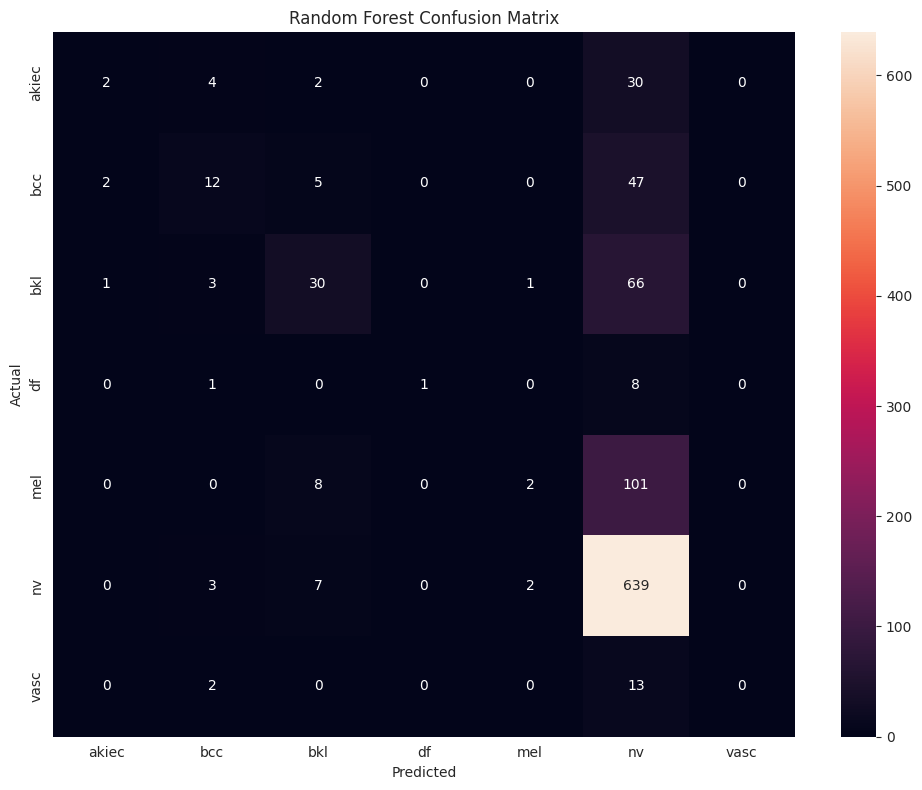

In [25]:
# Evaluate Random Forest Model

rf_predictions = rf_model.predict(X_test_flat)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_predictions))
print("Random Forest Balanced Accuracy:", balanced_accuracy_score(y_test, rf_predictions))
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        zero_division=0,
    )
)

cm = confusion_matrix(y_test, rf_predictions, labels=np.arange(len(class_names)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

## LSTM Model

In [26]:
# Train LSTM Classifier

RUN_LSTM = True

if RUN_LSTM:
    import tensorflow as tf

    tf.random.set_seed(42)

    # Treat image rows as sequence steps; width × channels are features.
    X_train_lstm = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
    X_val_lstm = X_val.reshape(X_val.shape[0], X_val.shape[1], -1)
    X_test_lstm = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)

    lstm_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=X_train_lstm.shape[1:]),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(len(class_names), activation="softmax"),
    ])

    lstm_model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    lstm_model.fit(
        X_train_lstm,
        y_train,
        validation_data=(X_val_lstm, y_val),
        epochs=10,
        batch_size=64,
        class_weight=class_weights,
        verbose=1,
    )

    test_loss, test_accuracy = lstm_model.evaluate(X_test_lstm, y_test, verbose=0)
    print("LSTM test loss:", test_loss)
    print("LSTM test accuracy:", test_accuracy)
else:
    print("LSTM training skipped. Set RUN_LSTM = True to enable it.")

Epoch 1/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.1682 - loss: 1.9537 - val_accuracy: 0.2519 - val_loss: 1.9989
Epoch 2/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.3777 - loss: 1.9069 - val_accuracy: 0.2286 - val_loss: 2.1663
Epoch 3/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3852 - loss: 1.8862 - val_accuracy: 0.4018 - val_loss: 1.8887
Epoch 4/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.4451 - loss: 1.8395 - val_accuracy: 0.4942 - val_loss: 1.6234
Epoch 5/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.4395 - loss: 1.7907 - val_accuracy: 0.4261 - val_loss: 1.6776
Epoch 6/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4179 - loss: 1.7566 - val_accuracy: 0.4504 - val_loss: 1.5430
Epoch 7/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4015 - loss: 1.7291 - val_accuracy: 0.4543 - val_loss: 1.5323
Epoch 8/10
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4506 - loss: 1.6761 - val_accu